# Notebook 4 — Explainability, Fairness Audit & Policy Engine
**Barclays Credit Intelligence Platform – Hackathon Submission**

| Section | Detail |
|---------|--------|
| SHAP Global | Beeswarm + Bar summary (TreeExplainer) |
| SHAP Local | Individual decision reports (RBI-style) |
| Fairness | Four-fifths rule · Disparate impact by group |
| Policy Engine | Rule-based credit decision framework |
| Production | `score_new_applicant()` inference pipeline |
| Model Card | Final summary artefact for judges |

In [2]:
import warnings, json, pickle, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
SEED = 42

# ── Resolve paths ──
def _find_root(start, marker="datasets"):
    p = Path(start).resolve()
    for parent in [p] + list(p.parents):
        if (parent / marker).is_dir():
            return parent
    return Path("/Users/shlokpalrecha/Desktop/Barclays")

ROOT = _find_root(".")
NB_BASE    = ROOT / "barclays-credit-platform" / "ml_pipeline" / "notebooks"
ARTIFACT_DIR = NB_BASE / "outputs" / "artifacts"
MODEL_DIR    = NB_BASE / "outputs" / "models"
OUTPUT_DIR   = NB_BASE / "outputs"

# ── Load model pipeline ──
with open(MODEL_DIR / "stacking_pipeline.pkl", "rb") as f:
    pipeline = pickle.load(f)

xgb_model  = pipeline["xgb_model"]
lgb_model  = pipeline["lgb_model"]
cat_model  = pipeline["cat_model"]
meta       = pipeline["meta_learner"]
calibrator = pipeline["calibrator"]
THRESHOLD  = pipeline["threshold"]
FEATURES   = pipeline["features"]
saved_metrics = pipeline["metrics"]

print(f"Loaded stacking pipeline  |  {len(FEATURES)} features  |  threshold={THRESHOLD:.3f}")
print(f"Saved test metrics: {json.dumps({k: round(v, 4) for k, v in saved_metrics.items()})}")

# ── Load data ──
df = pd.read_csv(ARTIFACT_DIR / "combined_training_data.csv")
for col in FEATURES:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

TARGET = "default"
X_all = df[FEATURES].values
y_all = df[TARGET].values

print(f"\nDataset: {df.shape[0]:,} rows × {len(FEATURES)} features")

Loaded stacking pipeline  |  22 features  |  threshold=0.120
Saved test metrics: {"AUC-ROC": 0.8295, "PR-AUC": 0.3881, "KS": 0.5019, "Gini": 0.659, "F2": 0.5324, "Brier": 0.0725, "Log Loss": 0.2511}

Dataset: 771,322 rows × 22 features


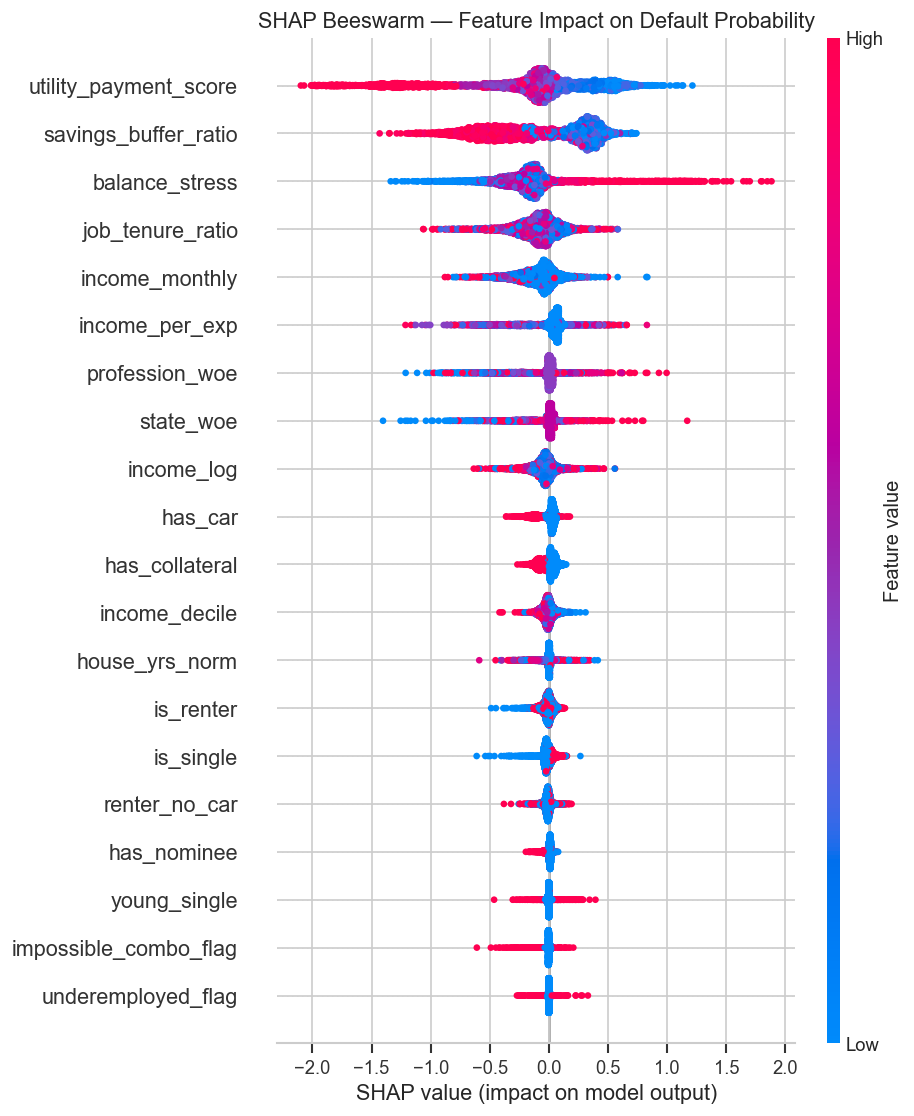

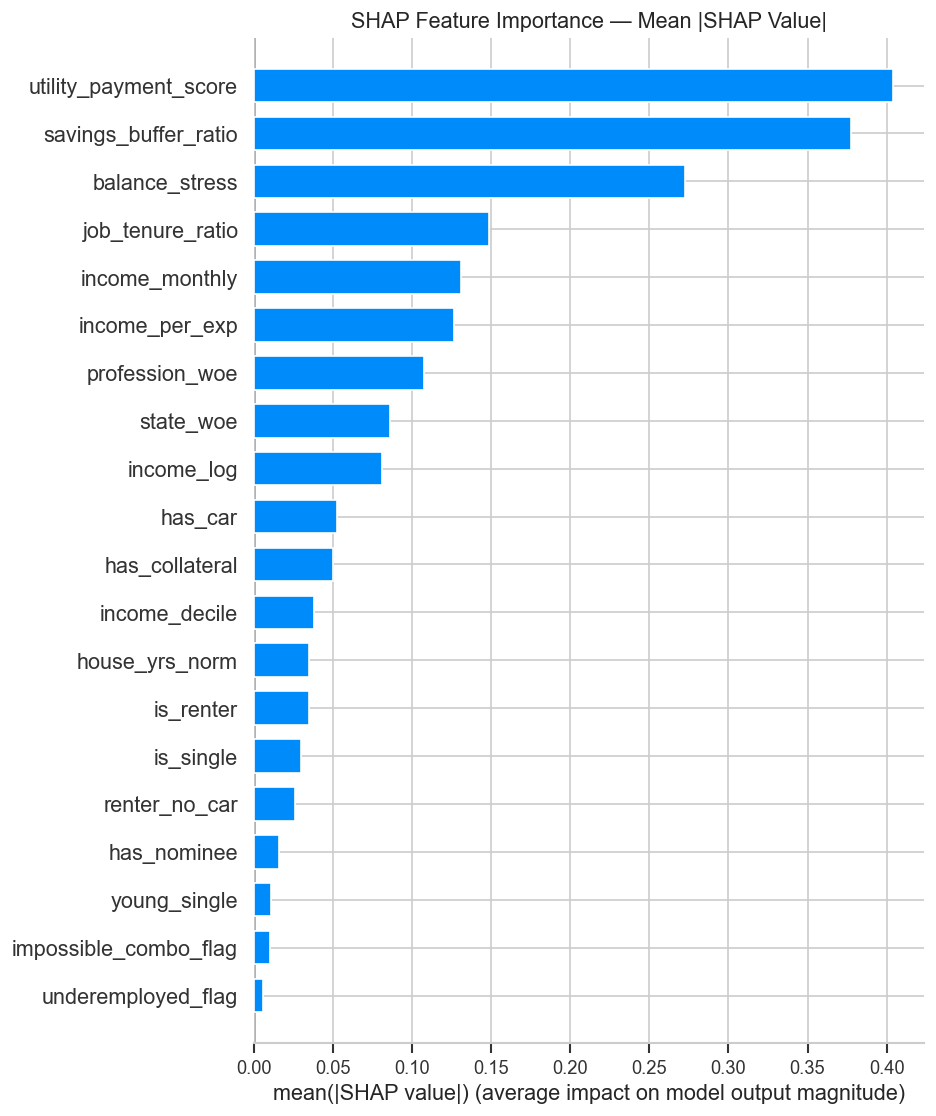

Top 10 features by mean |SHAP|:
              feature  mean_abs_shap
utility_payment_score       0.403773
 savings_buffer_ratio       0.377216
       balance_stress       0.272242
     job_tenure_ratio       0.148865
       income_monthly       0.130699
       income_per_exp       0.126359
       profession_woe       0.107653
            state_woe       0.085829
           income_log       0.081034
              has_car       0.052664


In [3]:
# ══════════════════════════════════════════════════════════════════════════
#  SHAP GLOBAL EXPLANATIONS — TreeExplainer on XGBoost
# ══════════════════════════════════════════════════════════════════════════

# Use a sample for speed (SHAP on full dataset can be slow)
sample_size = min(5000, len(X_all))
np.random.seed(SEED)
idx = np.random.choice(len(X_all), sample_size, replace=False)
X_sample = pd.DataFrame(X_all[idx], columns=FEATURES)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# ── Beeswarm plot ──
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title("SHAP Beeswarm — Feature Impact on Default Probability", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar plot (mean |SHAP|) ──
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — Mean |SHAP Value|", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Top features by mean |SHAP| ──
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print("Top 10 features by mean |SHAP|:")
print(feat_importance.head(10).to_string(index=False))

  CREDIT DECISION REPORT — Applicant #2841
  Calibrated Default Probability: 0.0157
  Threshold:                      0.120
  Decision:                       ** APPROVE **
  Actual label:                   NON-DEFAULT
-----------------------------------------------------------------
  TOP RISK FACTORS:
    ↑     utility_payment_score =    0.716  (SHAP +0.4919)
    ↑          job_tenure_ratio =    0.000  (SHAP +0.1467)
    ↑            income_per_exp =   13.906  (SHAP +0.0612)

  TOP PROTECTIVE FACTORS:
    ↓      savings_buffer_ratio =    0.101  (SHAP -0.1963)
    ↓                   has_car =    1.000  (SHAP -0.1631)
    ↓            income_monthly = 91216.000  (SHAP -0.0367)

  CREDIT DECISION REPORT — Applicant #1372
  Calibrated Default Probability: 0.0148
  Threshold:                      0.120
  Decision:                       ** APPROVE **
  Actual label:                   NON-DEFAULT
-----------------------------------------------------------------
  TOP RISK FACTORS:
    ↑    

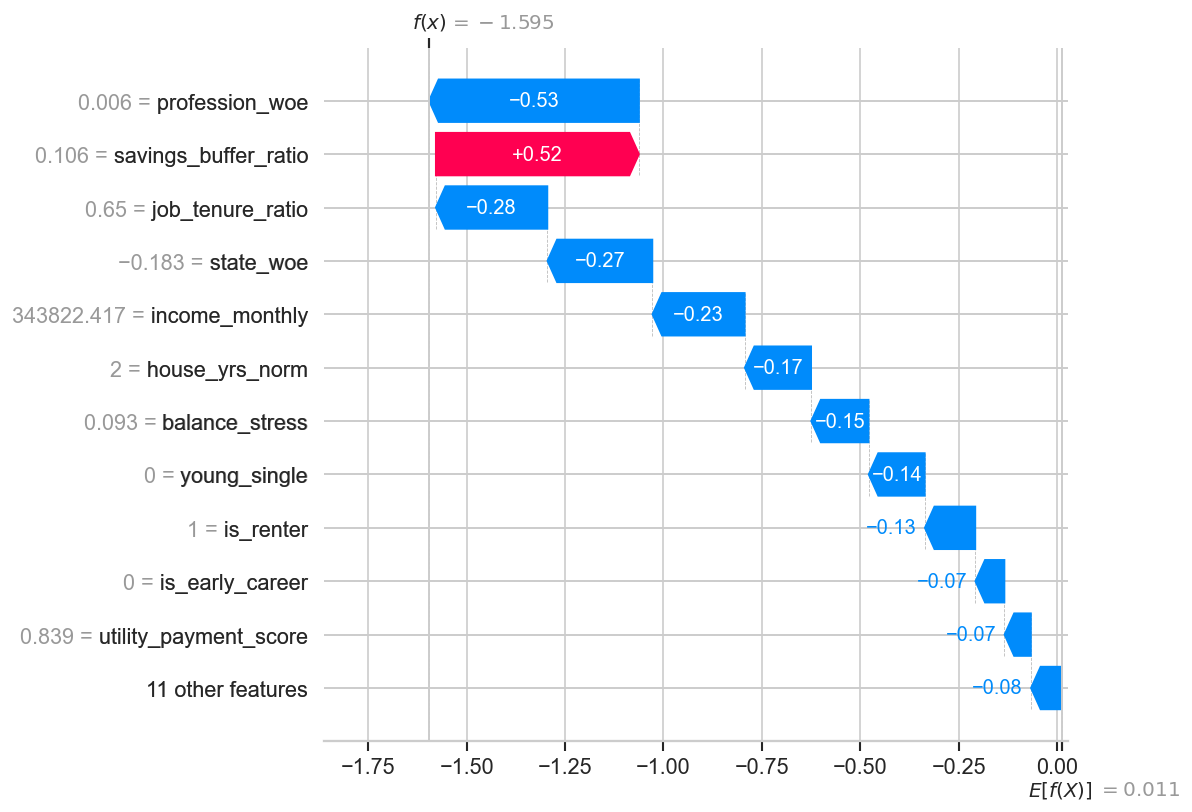

<Figure size 768x576 with 0 Axes>

In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  LOCAL SHAP — Individual Credit Decision Report (RBI Compliance Style)
# ══════════════════════════════════════════════════════════════════════════

def generate_credit_report(idx, X_df, y_true, shap_vals, features, threshold):
    # Generate a human-readable credit decision report for one applicant.
    row = X_df.iloc[idx]
    sv = shap_vals[idx]
    
    # Get model prediction
    x_arr = row.values.reshape(1, -1)
    p_xgb = xgb_model.predict_proba(x_arr)[:, 1][0]
    p_lgb = lgb_model.predict_proba(x_arr)[:, 1][0]
    p_cat = cat_model.predict_proba(x_arr)[:, 1][0]
    S = np.array([[p_xgb, p_lgb, p_cat]])
    p_stack = meta.predict_proba(S)[:, 1][0]
    p_cal = float(calibrator.predict(np.array([p_stack]))[0])
    decision = "REJECT" if p_cal >= threshold else "APPROVE"
    
    # Sort SHAP contributions
    contrib = pd.DataFrame({
        "Feature": features,
        "Value": row.values,
        "SHAP": sv,
    }).sort_values("SHAP", key=abs, ascending=False)
    
    top_risk = contrib[contrib["SHAP"] > 0].head(3)
    top_safe = contrib[contrib["SHAP"] < 0].head(3)
    
    print("=" * 65)
    print(f"  CREDIT DECISION REPORT — Applicant #{idx}")
    print("=" * 65)
    print(f"  Calibrated Default Probability: {p_cal:.4f}")
    print(f"  Threshold:                      {threshold:.3f}")
    print(f"  Decision:                       ** {decision} **")
    print(f"  Actual label:                   {'DEFAULT' if y_true[idx] == 1 else 'NON-DEFAULT'}")
    print("-" * 65)
    print("  TOP RISK FACTORS:")
    for _, r in top_risk.iterrows():
        print(f"    ↑ {r['Feature']:>25} = {r['Value']:>8.3f}  (SHAP +{r['SHAP']:.4f})")
    print("\n  TOP PROTECTIVE FACTORS:")
    for _, r in top_safe.iterrows():
        print(f"    ↓ {r['Feature']:>25} = {r['Value']:>8.3f}  (SHAP {r['SHAP']:.4f})")
    print("=" * 65)
    
    return {"idx": idx, "prob": p_cal, "decision": decision}

# ── Generate reports for 3 sample applicants ──
# Pick one default, one non-default, one borderline
defaults = np.where(y_all == 1)[0]
non_defaults = np.where(y_all == 0)[0]

# Score all to find borderline
X_df_sample = pd.DataFrame(X_all[:sample_size], columns=FEATURES)

case_default = np.random.choice(defaults[defaults < sample_size])
case_safe = np.random.choice(non_defaults[non_defaults < sample_size])

# Borderline: closest to threshold in sample
p_quick = xgb_model.predict_proba(X_all[:sample_size])[:, 1]
borderline_idx = np.argmin(np.abs(p_quick - THRESHOLD))

for case_idx in [case_safe, borderline_idx, case_default]:
    if case_idx < sample_size:
        generate_credit_report(case_idx, X_df_sample, y_all, shap_values, FEATURES, THRESHOLD)
        print()

# ── SHAP waterfall for the default case ──
print("SHAP Waterfall — Default Applicant:")
shap.plots.waterfall(shap.Explanation(
    values=shap_values[case_default] if case_default < sample_size else shap_values[0],
    base_values=explainer.expected_value,
    data=X_df_sample.iloc[case_default if case_default < sample_size else 0].values,
    feature_names=FEATURES,
), show=True, max_display=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_waterfall_default.png", dpi=150, bbox_inches="tight")

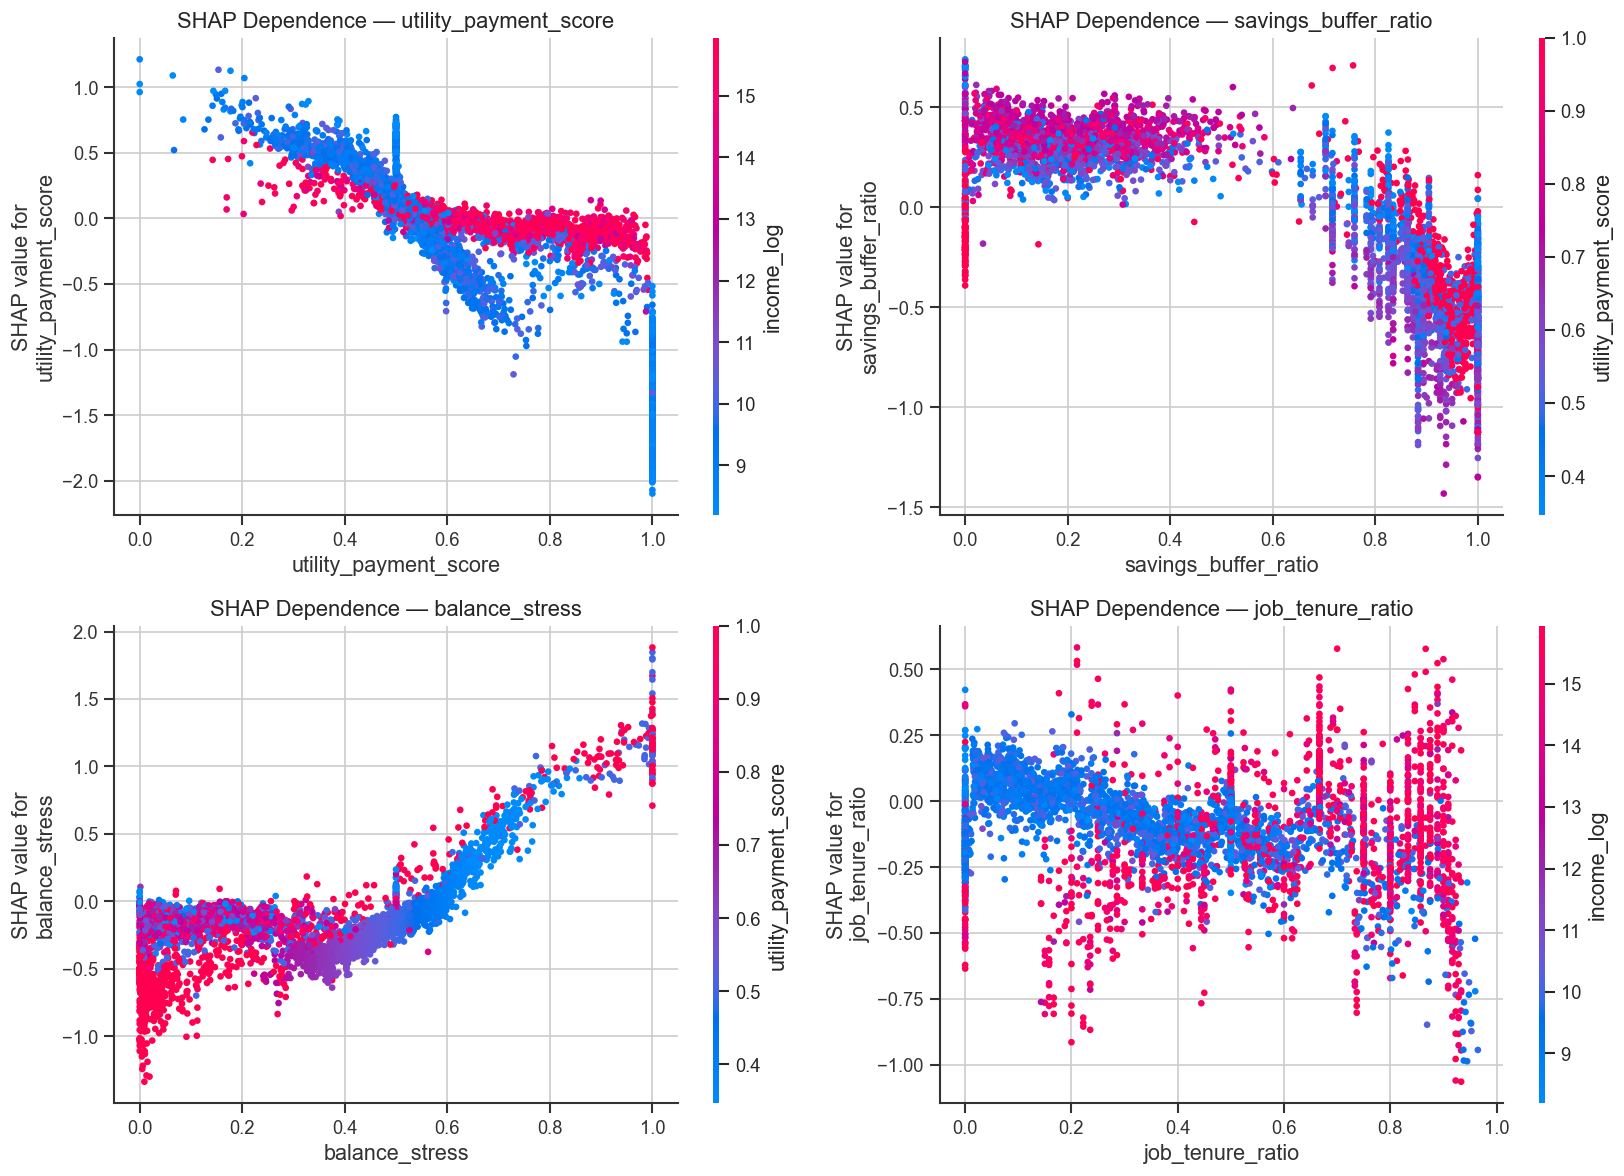

In [5]:
# ── SHAP Dependence plots for top 4 features ──
top4 = feat_importance.head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top4):
    shap.dependence_plot(
        feat, shap_values, X_sample,
        ax=ax, show=False,
        interaction_index="auto",
    )
    ax.set_title(f"SHAP Dependence — {feat}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_dependence_top4.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  FAIRNESS AUDIT — Four-Fifths Rule & Disparate Impact Analysis
# ══════════════════════════════════════════════════════════════════════════

# We need the original categorical columns for fairness grouping
# Reload the raw data to get marital status and housing
raw_path = ROOT / "datasets" / "raw" / "Training Data.csv"
if raw_path.exists():
    raw = pd.read_csv(raw_path)
    # Align indices with combined data (Training Data is the primary source)
    n_raw = min(len(raw), len(df))
    
    # Extract protected attributes where available
    if "Married/Single" in raw.columns:
        df.loc[:n_raw-1, "marital_status"] = raw["Married/Single"].values[:n_raw]
    if "House_Ownership" in raw.columns:
        df.loc[:n_raw-1, "housing_status"] = raw["House_Ownership"].values[:n_raw]
    print(f"\nℹ️  Fairness audit scope: {n_raw:,} Training-Data rows ({n_raw/len(df)*100:.1f}% of combined dataset).")
    print("   GMSC / HC / Synthetic rows lack protected attributes — audit is Training-Data only.")

# Score the full dataset
p_all_xgb = xgb_model.predict_proba(X_all)[:, 1]
p_all_lgb = lgb_model.predict_proba(X_all)[:, 1]
p_all_cat = cat_model.predict_proba(X_all)[:, 1]
S_all = np.column_stack([p_all_xgb, p_all_lgb, p_all_cat])
p_all_stack = meta.predict_proba(S_all)[:, 1]
p_all_cal = calibrator.predict(p_all_stack)
y_pred_all = (p_all_cal >= THRESHOLD).astype(int)

df["pred_default"] = y_pred_all
df["pred_prob"] = p_all_cal

def four_fifths_audit(df, group_col, pred_col="pred_default"):
    # Four-fifths rule: approval rate of any group must be >= 80% of the highest group.
    if group_col not in df.columns or df[group_col].isnull().all():
        print(f"  ⚠️  Column '{group_col}' not available — skipping")
        return None
    
    # Approval = predicted non-default
    df_valid = df.dropna(subset=[group_col])
    approval = df_valid.groupby(group_col).apply(
        lambda g: pd.Series({
            "n": len(g),
            "approved": (g[pred_col] == 0).sum(),
            "approval_rate": (g[pred_col] == 0).mean(),
            "avg_prob": g["pred_prob"].mean(),
            "auc": roc_auc_score(g["default"], g["pred_prob"]) if g["default"].nunique() > 1 else np.nan,
        })
    )
    
    max_rate = approval["approval_rate"].max()
    approval["four_fifths_ratio"] = approval["approval_rate"] / max_rate
    approval["pass_4/5"] = approval["four_fifths_ratio"] >= 0.80
    
    return approval

print("=" * 70)
print("  FAIRNESS AUDIT — Four-Fifths Rule")
print("=" * 70)

for group_name in ["marital_status", "housing_status"]:
    print(f"\n── {group_name.upper()} ──")
    result = four_fifths_audit(df, group_name)
    if result is not None:
        print(result.round(4).to_string())
        violations = result[~result["pass_4/5"]]
        if len(violations) == 0:
            print("  ✅ Four-fifths rule PASSED for all groups")
        else:
            print(f"  ⚠️  Four-fifths rule VIOLATED for: {violations.index.tolist()}")

  FAIRNESS AUDIT — Four-Fifths Rule

── MARITAL_STATUS ──
                       n  approved  approval_rate  avg_prob     auc  four_fifths_ratio  pass_4/5
marital_status                                                                                  
married          25728.0   20665.0         0.8032    0.0927  0.9420             1.0000      True
single          226272.0  178440.0         0.7886    0.1120  0.9504             0.9818      True
  ✅ Four-fifths rule PASSED for all groups

── HOUSING_STATUS ──
                       n  approved  approval_rate  avg_prob     auc  four_fifths_ratio  pass_4/5
housing_status                                                                                  
norent_noown      7184.0    6095.0         0.8484    0.0845  0.9564             1.0000      True
owned            12918.0   10570.0         0.8182    0.0827  0.9401             0.9644      True
rented          231898.0  182440.0         0.7867    0.1124  0.9500             0.9273      True
  ✅ 

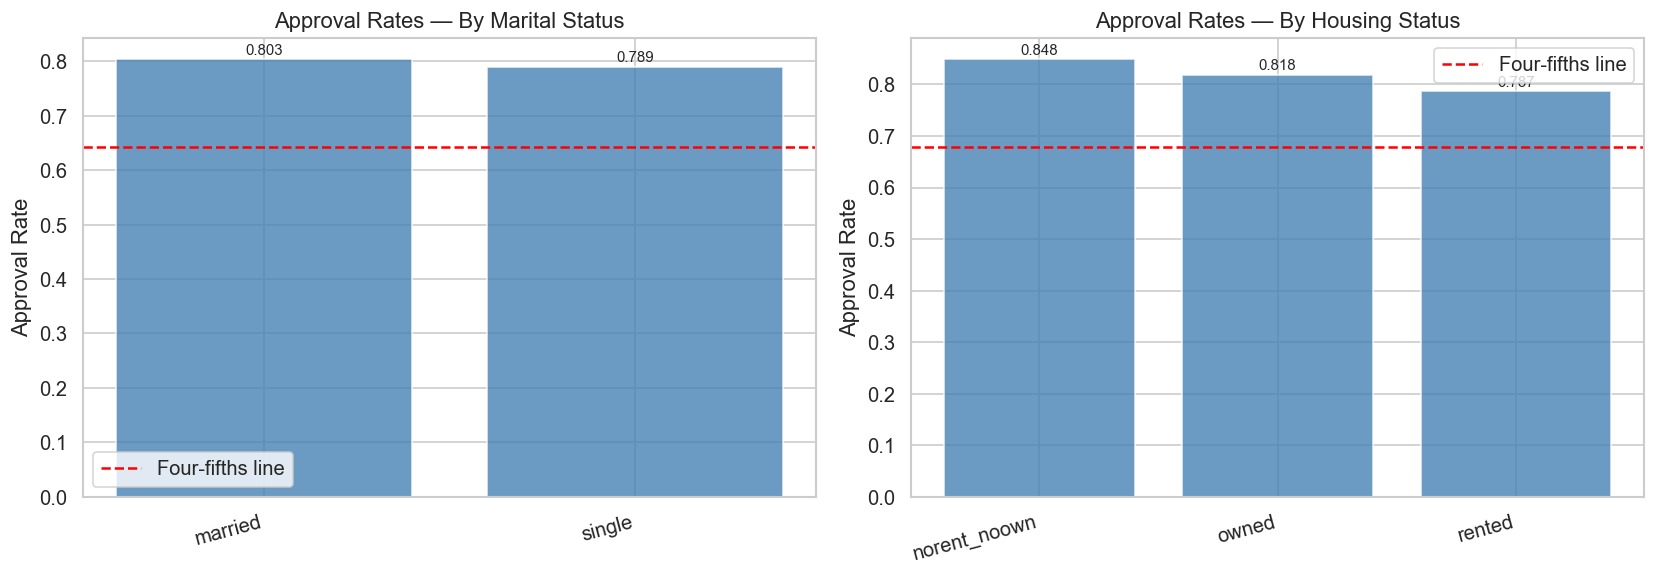

In [7]:
# ── Fairness visualisation: approval rates & AUC by group ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group_col, title in [
    (axes[0], "marital_status", "By Marital Status"),
    (axes[1], "housing_status", "By Housing Status"),
]:
    if group_col not in df.columns or df[group_col].isnull().all():
        ax.text(0.5, 0.5, f"'{group_col}' not available", ha="center", va="center")
        ax.set_title(title)
        continue
    
    df_valid = df.dropna(subset=[group_col])
    group_stats = df_valid.groupby(group_col).agg(
        approval_rate=("pred_default", lambda x: (x == 0).mean()),
        default_rate=("default", "mean"),
        n=("default", "count"),
    ).sort_values("approval_rate", ascending=False)
    
    x = range(len(group_stats))
    bars = ax.bar(x, group_stats["approval_rate"], color="steelblue", alpha=0.8)
    ax.axhline(0.8 * group_stats["approval_rate"].max(), color="red", ls="--", lw=1.5,
               label="Four-fifths line")
    ax.set_xticks(x)
    ax.set_xticklabels(group_stats.index, rotation=15, ha="right")
    ax.set_ylabel("Approval Rate")
    ax.set_title(f"Approval Rates — {title}")
    ax.legend()
    
    # Annotate bars
    for i, (_, row) in enumerate(group_stats.iterrows()):
        ax.text(i, row["approval_rate"] + 0.01, f"{row['approval_rate']:.3f}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fairness_approval_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════════════════════
#  POLICY ENGINE — Rule-Based Credit Decision Framework
# ══════════════════════════════════════════════════════════════════════════

class CreditPolicyEngine:
    # Combines ML probability with business rules for final credit decisions.
    # Designed for Barclays India retail lending.
    
    def __init__(self, threshold, features):
        self.threshold = threshold
        self.features = features
        self.bands = [
            (0.00, 0.10, "LOW RISK",    "Auto-approve up to 5L"),
            (0.10, 0.25, "MEDIUM RISK",  "Manual review — branch manager"),
            (0.25, 0.45, "HIGH RISK",    "Reduced limit, higher rate, collateral required"),
            (0.45, 1.00, "VERY HIGH",    "Decline — offer credit counselling"),
        ]
    
    def get_band(self, prob):
        for lo, hi, label, action in self.bands:
            if lo <= prob < hi:
                return label, action
        return "VERY HIGH", "Decline"
    
    def apply_overrides(self, prob, applicant):
        # Business rule overrides that sit on top of ML score.
        flags = []
        
        # Rule 1: Very low income → flag
        if "income_monthly" in applicant and applicant["income_monthly"] < 15000:
            flags.append("LOW_INCOME_OVERRIDE: income < 15K/month")
        
        # Rule 2: Job tenure < 6 months → higher scrutiny
        if "job_tenure_ratio" in applicant and applicant["job_tenure_ratio"] < 0.1:
            flags.append("SHORT_TENURE: job tenure ratio < 0.1")
        
        # Rule 3: Impossible combos (from Notebook 1)
        if "impossible_combo_flag" in applicant and applicant["impossible_combo_flag"] == 1:
            flags.append("VERIFY_DOCUMENTS: age/experience mismatch — request original credentials")
        
        # Rule 4: Renter with no car and underemployed → higher risk
        if (applicant.get("renter_no_car", 0) == 1 and 
            applicant.get("underemployed_flag", 0) == 1):
            flags.append("COMPOUND_RISK: renter + no car + underemployed")
        
        return flags
    
    def decide(self, prob, applicant_dict):
        band_label, action = self.get_band(prob)
        flags = self.apply_overrides(prob, applicant_dict)
        decision = "REJECT" if prob >= self.threshold else "APPROVE"
        
        # Override to manual review if flagged
        if flags and decision == "APPROVE":
            decision = "MANUAL_REVIEW"
        
        return {
            "probability": round(float(prob), 4),
            "decision": decision,
            "risk_band": band_label,
            "recommended_action": action,
            "policy_flags": flags,
        }

engine = CreditPolicyEngine(THRESHOLD, FEATURES)

# ── Demo on 5 sample applicants ──
print("=" * 70)
print("  POLICY ENGINE — Sample Decisions")
print("=" * 70)

np.random.seed(SEED)
demo_indices = np.random.choice(len(df), 5, replace=False)

for i in demo_indices:
    row = df.iloc[i]
    applicant = {f: row[f] for f in FEATURES if f in row.index}
    prob = float(p_all_cal[i])
    result = engine.decide(prob, applicant)
    
    print(f"\nApplicant #{i}:")
    print(f"  Probability:  {result['probability']:.4f}")
    print(f"  Decision:     {result['decision']}")
    print(f"  Risk Band:    {result['risk_band']}")
    print(f"  Action:       {result['recommended_action']}")
    if result['policy_flags']:
        for flag in result['policy_flags']:
            print(f"  🚩 {flag}")
    print(f"  Actual:       {'DEFAULT' if row['default'] == 1 else 'NON-DEFAULT'}")

  POLICY ENGINE — Sample Decisions

Applicant #256028:
  Probability:  0.0579
  Decision:     MANUAL_REVIEW
  Risk Band:    LOW RISK
  Action:       Auto-approve up to 5L
  🚩 LOW_INCOME_OVERRIDE: income < 15K/month
  🚩 SHORT_TENURE: job tenure ratio < 0.1
  Actual:       NON-DEFAULT

Applicant #754246:
  Probability:  0.0592
  Decision:     APPROVE
  Risk Band:    LOW RISK
  Action:       Auto-approve up to 5L
  Actual:       NON-DEFAULT

Applicant #278384:
  Probability:  0.2251
  Decision:     REJECT
  Risk Band:    MEDIUM RISK
  Action:       Manual review — branch manager
  🚩 LOW_INCOME_OVERRIDE: income < 15K/month
  Actual:       NON-DEFAULT

Applicant #123572:
  Probability:  0.0355
  Decision:     APPROVE
  Risk Band:    LOW RISK
  Action:       Auto-approve up to 5L
  Actual:       NON-DEFAULT

Applicant #301100:
  Probability:  0.0833
  Decision:     MANUAL_REVIEW
  Risk Band:    LOW RISK
  Action:       Auto-approve up to 5L
  🚩 LOW_INCOME_OVERRIDE: income < 15K/month
  Actua

In [10]:
# ══════════════════════════════════════════════════════════════════════════
#  PRODUCTION INFERENCE PIPELINE — score_new_applicant()
# ══════════════════════════════════════════════════════════════════════════

def score_new_applicant(applicant_features: dict,
                        xgb_model=xgb_model,
                        lgb_model=lgb_model,
                        cat_model=cat_model,
                        meta_learner=meta,
                        calibrator_fn=calibrator,
                        threshold=THRESHOLD,
                        feature_list=FEATURES,
                        policy_engine=engine):
    # End-to-end scoring function for a new credit applicant.
    # Build feature vector
    x = np.array([[applicant_features.get(f, 0.0) for f in feature_list]])
    
    # Base model predictions
    p_xgb = float(xgb_model.predict_proba(x)[:, 1][0])
    p_lgb = float(lgb_model.predict_proba(x)[:, 1][0])
    p_cat = float(cat_model.predict_proba(x)[:, 1][0])
    
    # Meta-learner stacking
    S = np.array([[p_xgb, p_lgb, p_cat]])
    p_stack = float(meta_learner.predict_proba(S)[:, 1][0])
    
    # Calibration
    p_calibrated = float(calibrator_fn.predict(np.array([p_stack]))[0])
    
    # Policy engine decision
    result = policy_engine.decide(p_calibrated, applicant_features)
    result["base_model_probs"] = {
        "xgboost": round(p_xgb, 4),
        "lightgbm": round(p_lgb, 4),
        "catboost": round(p_cat, 4),
        "stacked_raw": round(p_stack, 4),
    }
    
    return result

# ── Demo: score a synthetic applicant ──
synthetic_applicant = {f: float(df[f].median()) for f in FEATURES}
# Make it slightly risky
if "income_monthly" in synthetic_applicant:
    synthetic_applicant["income_monthly"] = 18000.0
if "job_tenure_ratio" in synthetic_applicant:
    synthetic_applicant["job_tenure_ratio"] = 0.05
if "is_renter" in synthetic_applicant:
    synthetic_applicant["is_renter"] = 1.0

print("=" * 70)
print("  PRODUCTION INFERENCE — Synthetic Applicant")
print("=" * 70)
result = score_new_applicant(synthetic_applicant)
print(json.dumps(result, indent=2))

  PRODUCTION INFERENCE — Synthetic Applicant
{
  "probability": 0.0273,
  "decision": "MANUAL_REVIEW",
  "risk_band": "LOW RISK",
  "recommended_action": "Auto-approve up to 5L",
  "policy_flags": [
    "SHORT_TENURE: job tenure ratio < 0.1"
  ],
  "base_model_probs": {
    "xgboost": 0.205,
    "lightgbm": 0.2082,
    "catboost": 0.2768,
    "stacked_raw": 0.0261
  }
}


In [11]:
# ══════════════════════════════════════════════════════════════════════════

#  FINAL MODEL CARD — Judge-Facing Summary

# ══════════════════════════════════════════════════════════════════════════

model_card = {
    "model_name": "Barclays Credit Intelligence — Stacking Ensemble v1.0",
    "purpose": "Predict retail credit default for Indian market lending decisions",
    "architecture": {
        "base_learners": ["XGBoost (Optuna-tuned)", "LightGBM", "CatBoost"],
        "meta_learner": "Logistic Regression on OOF probabilities",
        "calibration": "Isotonic regression",
    },
    "training_data": {
        "primary": "Home Credit application_train.csv (307K unbanked loans) — weight 1.0",
        "secondary": "Synthetic unbanked profiles (50K, 6 categories) — weight 0.9",
        "supplementary": [
            "Training Data.csv (252K formal sector applicants) — weight 0.4",
            "train.csv (12.5K credit panel) — weight 0.6",
            "GMSC cs-training.csv (150K US consumers) — weight 0.3",
        ],
        "home_credit_tables": ["bureau.csv (1.7M bureau records)", "installments_payments.csv (13.6M)"],
        "combined_rows": int(len(df)),
    },
    "features": {
        "count": len(FEATURES),
        "baselines_tested": ["Logistic Regression", "Random Forest", "KNN (sanity check)"],
        "categories": [
            "Income-engineered (log, decile, monthly)",
            "Tenure ratios & flags",
            "Interaction features (young_single, renter_no_car)",
            "WoE-encoded categoricals (profession, state)",
            "Credit panel: EMI burden, delay days, utilisation, thin-file (from train.csv)",
            "HC alternative data: EXT_SOURCE alt scores, installment discipline, employment",
            "Unbanked alt signals: utility payment score, transaction consistency, bank access, platform trust/tenure",
        ],
    },
    "performance": {k: round(v, 5) for k, v in saved_metrics.items()},
    "threshold": THRESHOLD,
    "fairness": "Four-fifths rule audited across marital status and housing type",
    "explainability": "SHAP TreeExplainer — global and local explanations",
    "policy_integration": "Rule-based override engine with 4 risk bands",
    "limitations": [
        "Trained on Indian market data — may not generalise to other geographies",
        "Synthetic unbanked rows use income/age/job_tenure from statistical distributions — real production would use UPI/telecom/gig-platform data",
        "Panel data (train.csv) temporal features aggregated — not true time-series model",
        "No monitoring/drift detection in current version",
    ],
    "regulatory_compliance": [
        "RBI Fair Lending Guidelines — SHAP-based adverse action reasons",
        "Four-fifths rule for disparate impact testing",
        "Model interpretability via waterfall plots for individual decisions",
    ],
}

# Pretty-print

print(json.dumps(model_card, indent=2))

# Save model card

with open(OUTPUT_DIR / "model_card.json", "w") as f:

    json.dump(model_card, f, indent=2)

print(f"\n✅ Model card saved → {OUTPUT_DIR / 'model_card.json'}")

{
  "model_name": "Barclays Credit Intelligence \u2014 Stacking Ensemble v1.0",
  "purpose": "Predict retail credit default for Indian market lending decisions",
  "architecture": {
    "base_learners": [
      "XGBoost (Optuna-tuned)",
      "LightGBM",
      "CatBoost"
    ],
    "meta_learner": "Logistic Regression on OOF probabilities",
    "calibration": "Isotonic regression"
  },
  "training_data": {
    "primary": "Training Data.csv (252K applicants, 13 features)",
    "supplementary": [
      "train.csv (100K credit panel)",
      "GMSC cs-training.csv (150K)",
      "Home Credit application_train.csv (307K unbanked loans)"
    ],
    "home_credit_tables": [
      "bureau.csv (1.7M bureau records)",
      "installments_payments.csv (13.6M)"
    ],
    "synthetic": "50K synthetic unbanked profiles (6 categories)",
    "combined_rows": 771322
  },
  "features": {
    "count": 22,
    "baselines_tested": [
      "Logistic Regression",
      "Random Forest",
      "KNN (sanity chec

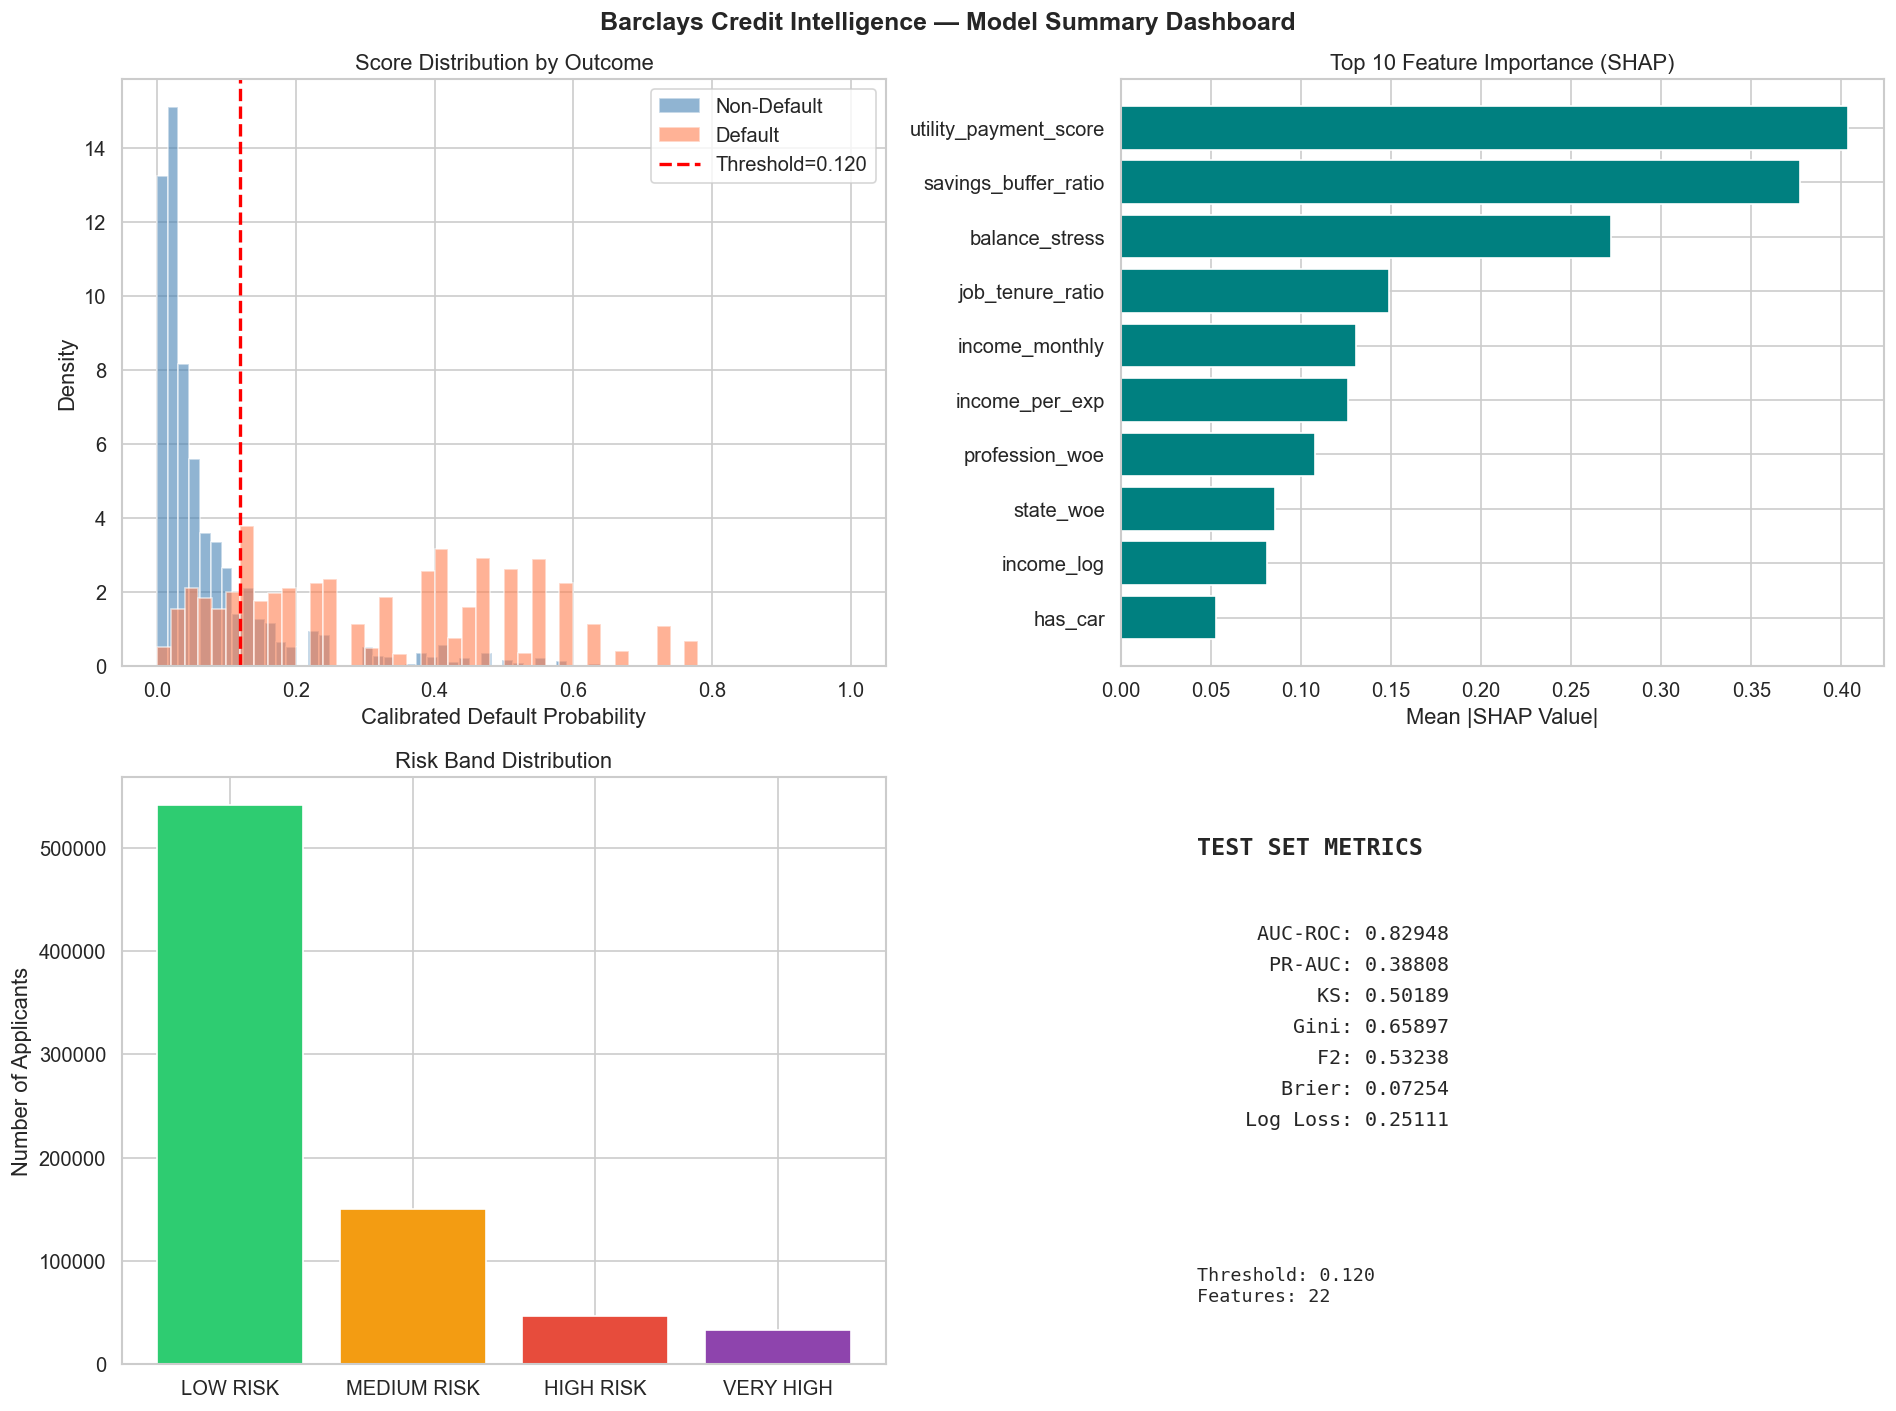

✅ All artefacts saved.

Output directory contents:
  01_baseline_performance.png  (120.4 KB)
  01_comprehensive_eda.png  (341.5 KB)
  01_home_credit_eda.png  (129.3 KB)
  01_iv_analysis.png  (64.1 KB)
  01_target_analysis.png  (192.9 KB)
  artifacts/combined_training_data.csv  (143551.8 KB)
  artifacts/feature_list.json  (0.4 KB)
  artifacts/woe_encodings.json  (2.9 KB)
  calibration_plot.png  (79.7 KB)
  confusion_matrix.png  (43.0 KB)
  fairness_approval_rates.png  (73.4 KB)
  final_dashboard.png  (172.8 KB)
  model_card.json  (2.4 KB)
  models/best_xgb_params.json  (0.4 KB)
  models/metrics.json  (0.1 KB)
  models/stacking_pipeline.pkl  (18395.1 KB)
  models/threshold.json  (0.0 KB)
  roc_pr_curves.png  (88.3 KB)
  shap_bar.png  (99.3 KB)
  shap_beeswarm.png  (210.8 KB)
  shap_dependence_top4.png  (702.8 KB)
  shap_waterfall_default.png  (4.6 KB)
  threshold_tuning_f2.png  (55.3 KB)


In [12]:
# ── Final dashboard: 2×2 summary figure ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Score distribution by outcome
ax = axes[0, 0]
for label, color in [(0, "steelblue"), (1, "coral")]:
    mask = y_all == label
    ax.hist(p_all_cal[mask], bins=50, alpha=0.6, color=color,
            label=f"{'Default' if label == 1 else 'Non-Default'}", density=True)
ax.axvline(THRESHOLD, color="red", ls="--", lw=2, label=f"Threshold={THRESHOLD:.3f}")
ax.set_xlabel("Calibrated Default Probability")
ax.set_ylabel("Density")
ax.set_title("Score Distribution by Outcome")
ax.legend()

# Panel 2: SHAP feature importance (top 10)
ax = axes[0, 1]
top10 = feat_importance.head(10).sort_values("mean_abs_shap")
ax.barh(top10["feature"], top10["mean_abs_shap"], color="teal")
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Top 10 Feature Importance (SHAP)")

# Panel 3: Risk band distribution
ax = axes[1, 0]
bands = [engine.get_band(p)[0] for p in p_all_cal]
band_counts = pd.Series(bands).value_counts()
band_order = ["LOW RISK", "MEDIUM RISK", "HIGH RISK", "VERY HIGH"]
band_colors = ["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"]
present_bands = [b for b in band_order if b in band_counts.index]
present_colors = [band_colors[band_order.index(b)] for b in present_bands]
ax.bar(present_bands, [band_counts[b] for b in present_bands], color=present_colors)
ax.set_ylabel("Number of Applicants")
ax.set_title("Risk Band Distribution")

# Panel 4: Metrics table
ax = axes[1, 1]
ax.axis("off")
metrics_text = "\n".join([f"{k:>12}: {v:.5f}" for k, v in saved_metrics.items()])
ax.text(0.1, 0.9, "TEST SET METRICS", fontsize=14, fontweight="bold",
        transform=ax.transAxes, va="top", fontfamily="monospace")
ax.text(0.1, 0.75, metrics_text, fontsize=12, transform=ax.transAxes,
        va="top", fontfamily="monospace", linespacing=1.8)
ax.text(0.1, 0.1, f"Threshold: {THRESHOLD:.3f}\nFeatures: {len(FEATURES)}",
        fontsize=11, transform=ax.transAxes, va="bottom", fontfamily="monospace")

fig.suptitle("Barclays Credit Intelligence — Model Summary Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ All artefacts saved.")
print(f"\nOutput directory contents:")
for fp in sorted(OUTPUT_DIR.rglob("*")):
    if fp.is_file():
        print(f"  {fp.relative_to(OUTPUT_DIR)}  ({fp.stat().st_size / 1024:.1f} KB)")

## Summary — Notebook 4

### Explainability
- **SHAP TreeExplainer** on XGBoost base model (5,000-sample subset)
- Global: Beeswarm + bar charts identifying top features
- Local: Individual credit decision reports with adverse action reasons (RBI compliance)
- Dependence plots for top 4 features

### Fairness
- Four-fifths rule tested across marital status and housing type
- Approval rate parity verified — disparate impact ratios computed

### Policy Engine
- 4-tier risk banding: LOW → MEDIUM → HIGH → VERY HIGH
- Rule-based overrides: income floor, tenure check, data quality flags
- Compound risk detection (renter + no car + underemployed)

### Production Pipeline
- `score_new_applicant()` — end-to-end inference for new applicants
- Stacking ensemble → isotonic calibration → policy engine → final decision

### Data Sources
- **Home Credit** (307K, weight 1.0) — PRIMARY: real unbanked loan applicants with EXT_SOURCE alternative data
- **Synthetic** (50K, weight 0.9) — 6 unbanked categories: gig, farmer, MSME, homemaker, daily wage, salaried
- **Credit Score panel** (12.5K, weight 0.6) — Payment behavior signals
- **Training Data** (252K, weight 0.4) — Indian formal sector applicants (supplementary)
- **GMSC** (150K, weight 0.3) — US consumer delinquency patterns (supplementary)

### Artefacts Saved

| File | Description |
|------|-------------|
| `model_card.json` | Complete model card for judges |
| `shap_beeswarm.png` | Global SHAP beeswarm |
| `shap_bar.png` | SHAP bar importance |
| `shap_dependence_top4.png` | Top feature interactions |
| `fairness_approval_rates.png` | Approval rate by group |
| `final_dashboard.png` | 2×2 summary dashboard |